# 1) Imports & chargement

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.exceptions import NotFittedError

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression


In [2]:
df_ventes = pd.read_csv('data/ech_annonces_ventes_68.csv', sep=';', index_col='idannonce')

# 2) Nettoyage et conversion de float à int

In [3]:
def clean_df(df: pd.DataFrame):
    # On supprime les colonnes ayant plus de 80% de valeurs manquantes
    valeurs_manquantes = df.isna().sum()/df.shape[0]
    valeurs_manquantes_list = list(valeurs_manquantes[valeurs_manquantes > 0.8].index)
    df_filtered = df.drop(valeurs_manquantes_list, axis = 1)
    # On supprime les colonnes "n6" pour ne laisser que les "n7" qui paraissent plus judicieuses (basées sur un plus grand nombre de bien)
    column_n6 = [ column for column in df_filtered.columns if "n6" in column]
    df_filtered = df_filtered.drop(column_n6, axis = 1)
    if 'typedebien' in df_filtered.columns:
        df_filtered = df_filtered[df_filtered['typedebien'] != 'l']
        df_filtered['typedebien'] = df_filtered['typedebien'].replace({'an': 'a', 'mn': 'm'})

    # On transform en Int des colonnes déclarées en float mais n'ayant que des int
    valeurs_manq_resid_quanti = [col for  col in df_filtered.select_dtypes(exclude='object').columns if df_filtered[col].isna().sum() > 0]    
    col_float = df_filtered[valeurs_manq_resid_quanti].select_dtypes(include='float64').columns
    for col in col_float:
        array_col = np.array(df_filtered[df_filtered[col].notna()][col]) 
        array_col_round = np.round(array_col)
        array_real_float = array_col[array_col != array_col_round]
        if len(array_real_float) == 0:
            df_filtered[col] = df_filtered[col].astype('Int64')
    # on transforme les colonnes quali n'ayant en fait que deux modalités
    if 'cave' in df_filtered.columns:
        df_filtered["cave"] = df_filtered["cave"].astype('Int64')
    if 'ascenseur' in df_filtered.columns:
        df_filtered["ascenseur"] = df_filtered["ascenseur"].astype('Int64')
    if 'logement_neuf' in df_filtered.columns:
        df_filtered["logement_neuf"] = df_filtered["logement_neuf"].replace({'n': False, 'o': True}).astype('Int64')

    return df_filtered

In [4]:
df_ventes = clean_df(df_ventes)
target = df_ventes['prix_bien']

# 3) Split train/test

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df_ventes.drop(columns=['prix_bien']),
    target,
    test_size=0.2,
    random_state=42
)

# 4) Transformer pour le remplissage (quali et quanti) du dataframe

In [6]:
class KNNImputerCustom(BaseEstimator, TransformerMixin):
    def __init__(self, type_col="typedebien", lat_col="mapCoordonneesLatitude", lon_col="mapCoordonneesLongitude", pieces_col="nb_pieces", k=10):
        self.type_col = type_col
        self.lat_col = lat_col
        self.lon_col = lon_col
        self.pieces_col = pieces_col
        self.k = k
        self.fitted = False
 
    def fit(self, X, y=None):
        self.df_train_ = X.copy()
        self.numeric_cols_ = X.select_dtypes(exclude="object").columns.tolist()
        self.default_mean_ = {col: X[col].mean() for col in self.numeric_cols_}
        self.imputer_ = KNNImputer()
        self.quali_cols_ = X.select_dtypes(include="object").columns.tolist()
        self.default_mode_ = {col: X[col].mode()[0] for col in self.quali_cols_}
        self.fitted = True
        
        return self
 
    def transform(self, X):
        if not(self.fitted):
            raise NotFittedError("This KNNImputerCustomed instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.")
        X = X.copy()
        # First we fill the numeric columns
        for col in self.numeric_cols_:
            if X[col].isna().sum() == 0:
                continue
            cols = [col, self.pieces_col, self.lat_col, self.lon_col]
            df_extract = X[[self.type_col] + cols]
            df_extract_train = self.df_train_ [[self.type_col] + cols]
            for typ in ["a", "m"]:
                subset = df_extract[df_extract[self.type_col] == typ][cols]
                if subset.shape[0] == 0:
                    continue
                apply_default = True
                subset_train = df_extract_train[df_extract_train[self.type_col] == typ][cols]
                if subset_train.shape[0] != 0:
                    self.imputer_.fit(subset_train)
                    imputed = self.imputer_.transform(subset)
                    if imputed.shape[1] == len(cols):
                        imputed_df = pd.DataFrame(imputed, columns=cols, index=subset.index)
                        apply_default = False
                if apply_default:
                    if X[col].dtype in ["int64", "Int64"]:
                        X.loc[subset.index, col] = self.default_mean_[col].astype("int64")
                    else:
                        X.loc[subset.index, col] = self.default_mean_[col]
                else:
                    if X[col].dtype in ["int64", "Int64"]:
                        X.loc[imputed_df.index, col] = imputed_df[col].round().astype("int64")
                    else:
                        X.loc[imputed_df.index, col] = imputed_df[col]

        #Secondly we fill the qualitative columns
        index_na = X[X[self.quali_cols_].isna().any(axis=1)].index
        for idx in index_na:
            lat = X.loc[idx, self.lat_col]
            lon = X.loc[idx, self.lon_col]
            nbp = X.loc[idx, self.pieces_col]
            typ = X.loc[idx, self.type_col]
            neighbours = self.df_train_[
                (self.df_train_[self.pieces_col] == nbp) &
                (self.df_train_[self.type_col] == typ)
            ]
            distances = (lat - neighbours[self.lat_col])**2 + (lon - neighbours[self.lon_col])**2
            for col in self.quali_cols_:
                if pd.isna(X.loc[idx, col]):
                    valid = neighbours[neighbours[col].notna()]
                    if valid.shape[0] > 0:
                        idx_neigh = distances[valid.index].sort_values().iloc[:self.k].index
                        X.loc[idx, col] = neighbours.loc[idx_neigh][col].mode()[0]
                    else:
                        X.loc[idx, col] = self.default_mode_[col]
        
        return X

In [7]:
knn_imputer_custom = KNNImputerCustom()
X_train = knn_imputer_custom.fit_transform(X_train)
X_test = knn_imputer_custom.transform(X_test)

# 5) Fonction de nettoyage des outiliers (IQR)

In [8]:
# Suppression de certains champs dont nous ne connaissons pas la définition
X_train.drop(columns=['duree_int', 'loyer_m2_median_n7', 'nb_log_n7', 'taux_rendement_n7'], axis=1, inplace=True)
X_test.drop(columns=['duree_int', 'loyer_m2_median_n7', 'nb_log_n7', 'taux_rendement_n7'], axis=1, inplace=True)

In [9]:
X_train_clean = X_train

numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()

index_to_drop = []

for col in numeric_cols:
    q1 = max(X_train[col].quantile(0.1), 0)
    q3 = max(X_train[col].quantile(0.9), 0)
    iqr = q3 - q1
    lower = max(q1 - 2 * iqr, 0)
    upper = max(q3 + 2 * iqr, 0)
    temp_index_to_drop = X_train[(X_train[col] < lower) | (X_train[col] > upper)].index.to_list()
    index_to_drop.extend(temp_index_to_drop)
    print("Suppression des lignes où ", col , " < ", lower, " ou ", col, " > ", upper, " (", len(temp_index_to_drop), " rows)")

X_train_clean = X_train_clean.drop(index_to_drop)

nb_rows_avant = X_train.shape[0]
nb_rows_apres = X_train_clean.shape[0]
nb_rows_suppr = nb_rows_avant - nb_rows_apres

print("\ndataframe initial : ", nb_rows_avant, " rows.")
print("dataframe nettoyé avec iqr : ", nb_rows_apres, " rows.")
print("Proportion conservé : ", 100 * np.round(nb_rows_apres/nb_rows_avant, 5), "%")
print("Nombre d'observations supprimées : ", nb_rows_suppr)

X_train = X_train_clean
y_train = y_train.loc[X_train.index]

Suppression des lignes où  etage  <  0  ou  etage  >  6.0  ( 272  rows)
Suppression des lignes où  surface  <  0  ou  surface  >  421.0  ( 105  rows)
Suppression des lignes où  surface_terrain  <  0  ou  surface_terrain  >  2850.0  ( 351  rows)
Suppression des lignes où  nb_pieces  <  0  ou  nb_pieces  >  17.0  ( 47  rows)
Suppression des lignes où  mensualiteFinance  <  0.0  ou  mensualiteFinance  >  0.0  ( 331  rows)
Suppression des lignes où  balcon  <  0  ou  balcon  >  3.0  ( 3  rows)
Suppression des lignes où  eau  <  0  ou  eau  >  3.0  ( 16  rows)
Suppression des lignes où  bain  <  0  ou  bain  >  3.0  ( 89  rows)
Suppression des lignes où  dpeC  <  0  ou  dpeC  >  745.8  ( 13  rows)
Suppression des lignes où  mapCoordonneesLatitude  <  46.595870000000005  ou  mapCoordonneesLatitude  >  49.07131999999999  ( 0  rows)
Suppression des lignes où  mapCoordonneesLongitude  <  6.43378  ou  mapCoordonneesLongitude  >  8.263480000000001  ( 0  rows)
Suppression des lignes où  nb_etages 

In [10]:
X_test_clean = X_test

numeric_cols = X_test.select_dtypes(include=['number']).columns.tolist()

index_to_drop = []

for col in numeric_cols:
    q1 = max(X_test[col].quantile(0.1), 0)
    q3 = max(X_test[col].quantile(0.9), 0)
    iqr = q3 - q1
    lower = max(q1 - 2 * iqr, 0)
    upper = max(q3 + 2 * iqr, 0)
    temp_index_to_drop = X_test[(X_test[col] < lower) | (X_test[col] > upper)].index.to_list()
    index_to_drop.extend(temp_index_to_drop)
    print("Suppression des lignes où ", col , " < ", lower, " ou ", col, " > ", upper, " (", len(temp_index_to_drop), " rows)")

X_test_clean = X_test_clean.drop(index_to_drop)

nb_rows_avant = X_test.shape[0]
nb_rows_apres = X_test_clean.shape[0]
nb_rows_suppr = nb_rows_avant - nb_rows_apres

print("\ndataframe initial : ", nb_rows_avant, " rows.")
print("dataframe nettoyé avec iqr : ", nb_rows_apres, " rows.")
print("Proportion conservé : ", 100 * np.round(nb_rows_apres/nb_rows_avant, 5), "%")
print("Nombre d'observations supprimées : ", nb_rows_suppr)

X_test = X_test_clean
y_test = y_test.loc[X_test.index]

Suppression des lignes où  etage  <  0  ou  etage  >  6.0  ( 85  rows)
Suppression des lignes où  surface  <  0  ou  surface  >  430.0  ( 26  rows)
Suppression des lignes où  surface_terrain  <  0  ou  surface_terrain  >  2857.5868  ( 85  rows)
Suppression des lignes où  nb_pieces  <  0  ou  nb_pieces  >  17.0  ( 12  rows)
Suppression des lignes où  mensualiteFinance  <  0.0  ou  mensualiteFinance  >  0.0  ( 88  rows)
Suppression des lignes où  balcon  <  0  ou  balcon  >  3.0  ( 1  rows)
Suppression des lignes où  eau  <  0  ou  eau  >  3.0  ( 4  rows)
Suppression des lignes où  bain  <  0  ou  bain  >  3.0  ( 22  rows)
Suppression des lignes où  dpeC  <  0  ou  dpeC  >  748.9800000000002  ( 3  rows)
Suppression des lignes où  mapCoordonneesLatitude  <  46.59563  ou  mapCoordonneesLatitude  >  49.07168  ( 0  rows)
Suppression des lignes où  mapCoordonneesLongitude  <  6.445864  ou  mapCoordonneesLongitude  >  8.251978999999999  ( 0  rows)
Suppression des lignes où  nb_etages  <  0  ou

# 6) Normalisation des données GPS (fit sur train)

In [11]:
scaler_lat = StandardScaler()
scaler_lon = StandardScaler()

X_train['Latitude_scaled']  = scaler_lat.fit_transform(X_train[['mapCoordonneesLatitude']])
X_train['Longitude_scaled'] = scaler_lon.fit_transform(X_train[['mapCoordonneesLongitude']])

X_test['Latitude_scaled']  = scaler_lat.transform(X_test[['mapCoordonneesLatitude']])
X_test['Longitude_scaled'] = scaler_lon.transform(X_test[['mapCoordonneesLongitude']])

# 7) Target Encoding (fit sur train)

In [12]:
cols_te = ['INSEE_COM', 'typedebien_lite', 'nb_pieces']

mean_price_by_combo = (
    X_train.assign(prix_bien=y_train)
    .groupby(cols_te, as_index=False)['prix_bien']
    .mean()
    .rename(columns={'prix_bien': 'prix_bien_target_encoding'})
)

X_train = X_train.merge(mean_price_by_combo, on=cols_te, how='left')
X_test  = X_test.merge(mean_price_by_combo, on=cols_te, how='left')

X_test[['prix_bien_target_encoding']] = X_test[['prix_bien_target_encoding']].fillna(y_train.mean())

# 8) Extraction année + OHE (fit sur train)

In [13]:
X_train['date'] = pd.to_datetime(X_train['date'])
X_test['date'] = pd.to_datetime(X_test['date'])

X_train['annee'] = X_train['date'].dt.year
X_test['annee'] = X_test['date'].dt.year

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
annee_train = ohe.fit_transform(X_train[['annee']])
annee_test  = ohe.transform(X_test[['annee']])

annee_cols = ohe.get_feature_names_out(['annee'])

X_train = pd.concat([X_train, pd.DataFrame(annee_train, columns=annee_cols, index=X_train.index)], axis=1)
X_test  = pd.concat([X_test,  pd.DataFrame(annee_test,  columns=annee_cols, index=X_test.index)], axis=1)

# 9) Parsing exposition / chauffage / DPE / GES

In [14]:
def parse_exposition(df):
    df = df.copy()
    df['exposition_clean'] = (
        df['exposition'].astype(str)
        .str.lower()
        .str.replace(r'[,/\\\-]', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )
    df['expo_nord']  = df['exposition_clean'].str.contains(r'\bnord\b',  na=False).astype(int)
    df['expo_sud']   = df['exposition_clean'].str.contains(r'\bsud\b',   na=False).astype(int)
    df['expo_est']   = df['exposition_clean'].str.contains(r'\best\b',   na=False).astype(int)
    df['expo_ouest'] = df['exposition_clean'].str.contains(r'\bouest\b', na=False).astype(int)
    df['expo_inconnue'] = df['exposition_clean'].str.contains(r'0|nan', na=False).astype(int)
    return df

In [15]:
def parse_chauffage_systeme(df):
    df = df.copy()
    df['chauffage_systeme_clean'] = (
        df['chauffage_systeme'].astype(str)
        .str.lower()
        .str.replace(r'[,/\\\-]', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

    df['chauf_radiateur']  = df['chauffage_systeme_clean'].str.contains(r'\bradiateur\b', na=False).astype(int)
    df['chauf_sol']        = df['chauffage_systeme_clean'].str.contains(r'\bsol\b', na=False).astype(int)
    df['chauf_convecteur'] = df['chauffage_systeme_clean'].str.contains(r'\bconvecteur\b', na=False).astype(int)
    df['chauf_poele_bois'] = df['chauffage_systeme_clean'].str.contains(r'poêle|poele', na=False).astype(int)
    df['chauf_pac']        = df['chauffage_systeme_clean'].str.contains(r'pompe à chaleur|pac', na=False).astype(int)
    df['chauf_clim_rev']   = df['chauffage_systeme_clean'].str.contains(r'climatisation', na=False).astype(int)
    df['chauf_cheminee']   = df['chauffage_systeme_clean'].str.contains(r'cheminée|cheminee', na=False).astype(int)
    df['chauf_inconnu']    = df['chauffage_systeme_clean'].str.contains(r'nan', na=False).astype(int)
    return df

In [16]:
def parse_chauffage_energie(df):
    df = df.copy()
    df['chauffage_energie_clean'] = (
        df['chauffage_energie'].astype(str)
        .str.lower()
        .str.replace(r'[,/\\\-]', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

    df['energie_gaz']   = df['chauffage_energie_clean'].str.contains(r'\bgaz\b', na=False).astype(int)
    df['energie_elec']  = df['chauffage_energie_clean'].str.contains(r'électrique|electrique', na=False).astype(int)
    df['energie_fioul'] = df['chauffage_energie_clean'].str.contains(r'\bfioul\b', na=False).astype(int)
    df['energie_bois']  = df['chauffage_energie_clean'].str.contains(r'\bbois\b', na=False).astype(int)
    df['energie_inconnue'] = df['chauffage_energie_clean'].str.contains(r'nan', na=False).astype(int)
    return df

In [17]:
def parse_chauffage_mode(df):
    df = df.copy()
    df['chauffage_mode_clean'] = (
        df['chauffage_mode'].astype(str)
        .str.lower()
        .str.replace(r'[,/\\\-]', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

    df['chauffage_mode_individuel'] = df['chauffage_mode_clean'].str.contains(r'\bindividuel\b', na=False).astype(int)
    df['chauffage_mode_collectif']  = df['chauffage_mode_clean'].str.contains(r'\bcollectif\b', na=False).astype(int)
    df['chauffage_mode_central']    = df['chauffage_mode_clean'].str.contains(r'\bcentral\b', na=False).astype(int)
    df['chauffage_mode_inconnu']    = df['chauffage_mode_clean'].str.contains(r'nan', na=False).astype(int)
    return df

In [18]:
def parse_dpe(df):
    df = df.copy()
    df['dpe_A'] = df['dpeL'].str.contains(r'A', na=False).astype(int)
    df['dpe_B'] = df['dpeL'].str.contains(r'B', na=False).astype(int)
    df['dpe_C'] = df['dpeL'].str.contains(r'C', na=False).astype(int)
    df['dpe_D'] = df['dpeL'].str.contains(r'D', na=False).astype(int)
    df['dpe_E'] = df['dpeL'].str.contains(r'E', na=False).astype(int)
    df['dpe_F'] = df['dpeL'].str.contains(r'F', na=False).astype(int)
    df['dpe_G'] = df['dpeL'].str.contains(r'G', na=False).astype(int)
    df['dpe_inconnu'] = (~df['dpeL'].isin(list("ABCDEFG"))).astype(int)
    return df

In [19]:
def parse_ges(df):
    df = df.copy()
    df['ges_A'] = df['ges_class'].str.contains(r'A', na=False).astype(int)
    df['ges_B'] = df['ges_class'].str.contains(r'B', na=False).astype(int)
    df['ges_C'] = df['ges_class'].str.contains(r'C', na=False).astype(int)
    df['ges_D'] = df['ges_class'].str.contains(r'D', na=False).astype(int)
    df['ges_E'] = df['ges_class'].str.contains(r'E', na=False).astype(int)
    df['ges_F'] = df['ges_class'].str.contains(r'F', na=False).astype(int)
    df['ges_G'] = df['ges_class'].str.contains(r'G', na=False).astype(int)
    df['ges_inconnu'] = (~df['ges_class'].isin(list("ABCDEFG"))).astype(int)
    return df

In [20]:
X_train = parse_exposition(X_train)
X_test  = parse_exposition(X_test)

X_train = parse_chauffage_systeme(X_train)
X_test  = parse_chauffage_systeme(X_test)

X_train = parse_chauffage_energie(X_train)
X_test  = parse_chauffage_energie(X_test)

X_train = parse_dpe(X_train)
X_test  = parse_dpe(X_test)

X_train = parse_ges(X_train)
X_test  = parse_ges(X_test)

X_train = parse_chauffage_mode(X_train)
X_test  = parse_chauffage_mode(X_test)

# 10) OHE sur le reste des variables catégorielles

In [21]:
# --- Liste des colonnes à exclure (déjà parsées ou inutiles)
exclude_cols = [
    'mapCoordonneesLatitude', 'mapCoordonneesLongitude',
    'date', 'annee',
    'exposition', 'exposition_clean',
    'chauffage_systeme', 'chauffage_systeme_clean',
    'chauffage_energie', 'chauffage_energie_clean',
    'dpeL', 'ges_class',
    'chauffage_mode', 'chauffage_mode_clean'
]

# --- Sélection des colonnes catégorielles restantes
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns
cat_cols = [c for c in cat_cols if c not in exclude_cols]

print("Colonnes catégorielles encodées :", cat_cols)

# --- OneHotEncoder (fit sur train)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

ohe_train = ohe.fit_transform(X_train[cat_cols])
ohe_test  = ohe.transform(X_test[cat_cols])

ohe_cols = ohe.get_feature_names_out(cat_cols)

# --- Ajout des colonnes encodées
X_train_ohe = pd.DataFrame(ohe_train, columns=ohe_cols, index=X_train.index)
X_test_ohe  = pd.DataFrame(ohe_test,  columns=ohe_cols, index=X_test.index)

X_train = pd.concat([X_train.drop(columns=cat_cols+exclude_cols), X_train_ohe], axis=1)
X_test  = pd.concat([X_test.drop(columns=cat_cols+exclude_cols),  X_test_ohe], axis=1)

Colonnes catégorielles encodées : ['type_annonceur', 'typedebien', 'typedetransaction', 'annonce_exclusive', 'categorie_annonceur', 'typedebien_lite', 'TYP_IRIS_x', 'TYP_IRIS_y']


# 11) Standardisation des données

In [22]:
df_scaler = StandardScaler()

train_columns = X_train.columns
train_index = X_train.index
test_index = X_test.index

X_train = pd.DataFrame(data=df_scaler.fit_transform(X_train), index=train_index, columns=train_columns)
X_test = pd.DataFrame(data=df_scaler.transform(X_test), index=test_index, columns=train_columns)

# 12) Sauvegardes des jeux de données train/test pour ne pas tout rejouer

In [23]:
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

# 13) Chargement des jeux de données train/test déjà générés

In [24]:
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

# 14) Sélection de variables

## 14.1) Laila

## 14.2) Hugues

## 14.3) Matthieu

### 14.3.1) Backward Elimination

LinearRegression sur l'ensemble des Features

In [25]:
# Modèle
lr = LinearRegression()
lr.fit(X_train, y_train)

# Prédictions
y_pred = lr.predict(X_test)

# Scores
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")

MAE  : 31428.47
RMSE : 50699.14
R2   : 0.8985


Coefficients des Features

In [26]:
import pandas as pd

# Création du dictionnaire avec les coefficients absolus
columns_coef = dict(zip(X_train.columns, np.abs(lr.coef_[0].tolist())))

# Tri par ordre décroissant des coefficients
columns_coef_trie = dict(sorted(columns_coef.items(), key=lambda item: item[1], reverse=True))

# Création du DataFrame avec l'ordre, la feature et le coefficient
df_resultats = pd.DataFrame([
    {'Ordre d\'importance': i, 'Feature': feature, 'Coefficient en valeur absolue': coef}
    for i, (feature, coef) in enumerate(columns_coef_trie.items(), start=1)
])

# Affichage du DataFrame
df_resultats.head(10)


,Ordre d'importance,Feature,Coefficient en valeur absolue
0,1,surface,101690.270683
1,2,prix_m2_vente,96291.434537
2,3,prix_bien_target_encoding,40609.028414
3,4,nb_pieces,17839.449118
4,5,surface_terrain,7787.940575
5,6,ascenseur,7657.392469
6,7,Longitude_scaled,5930.848221
7,8,IRIS,5346.676171
8,9,UU2010,5313.970229
9,10,categorie_annonceur_cm,5253.494794


<Axes: >

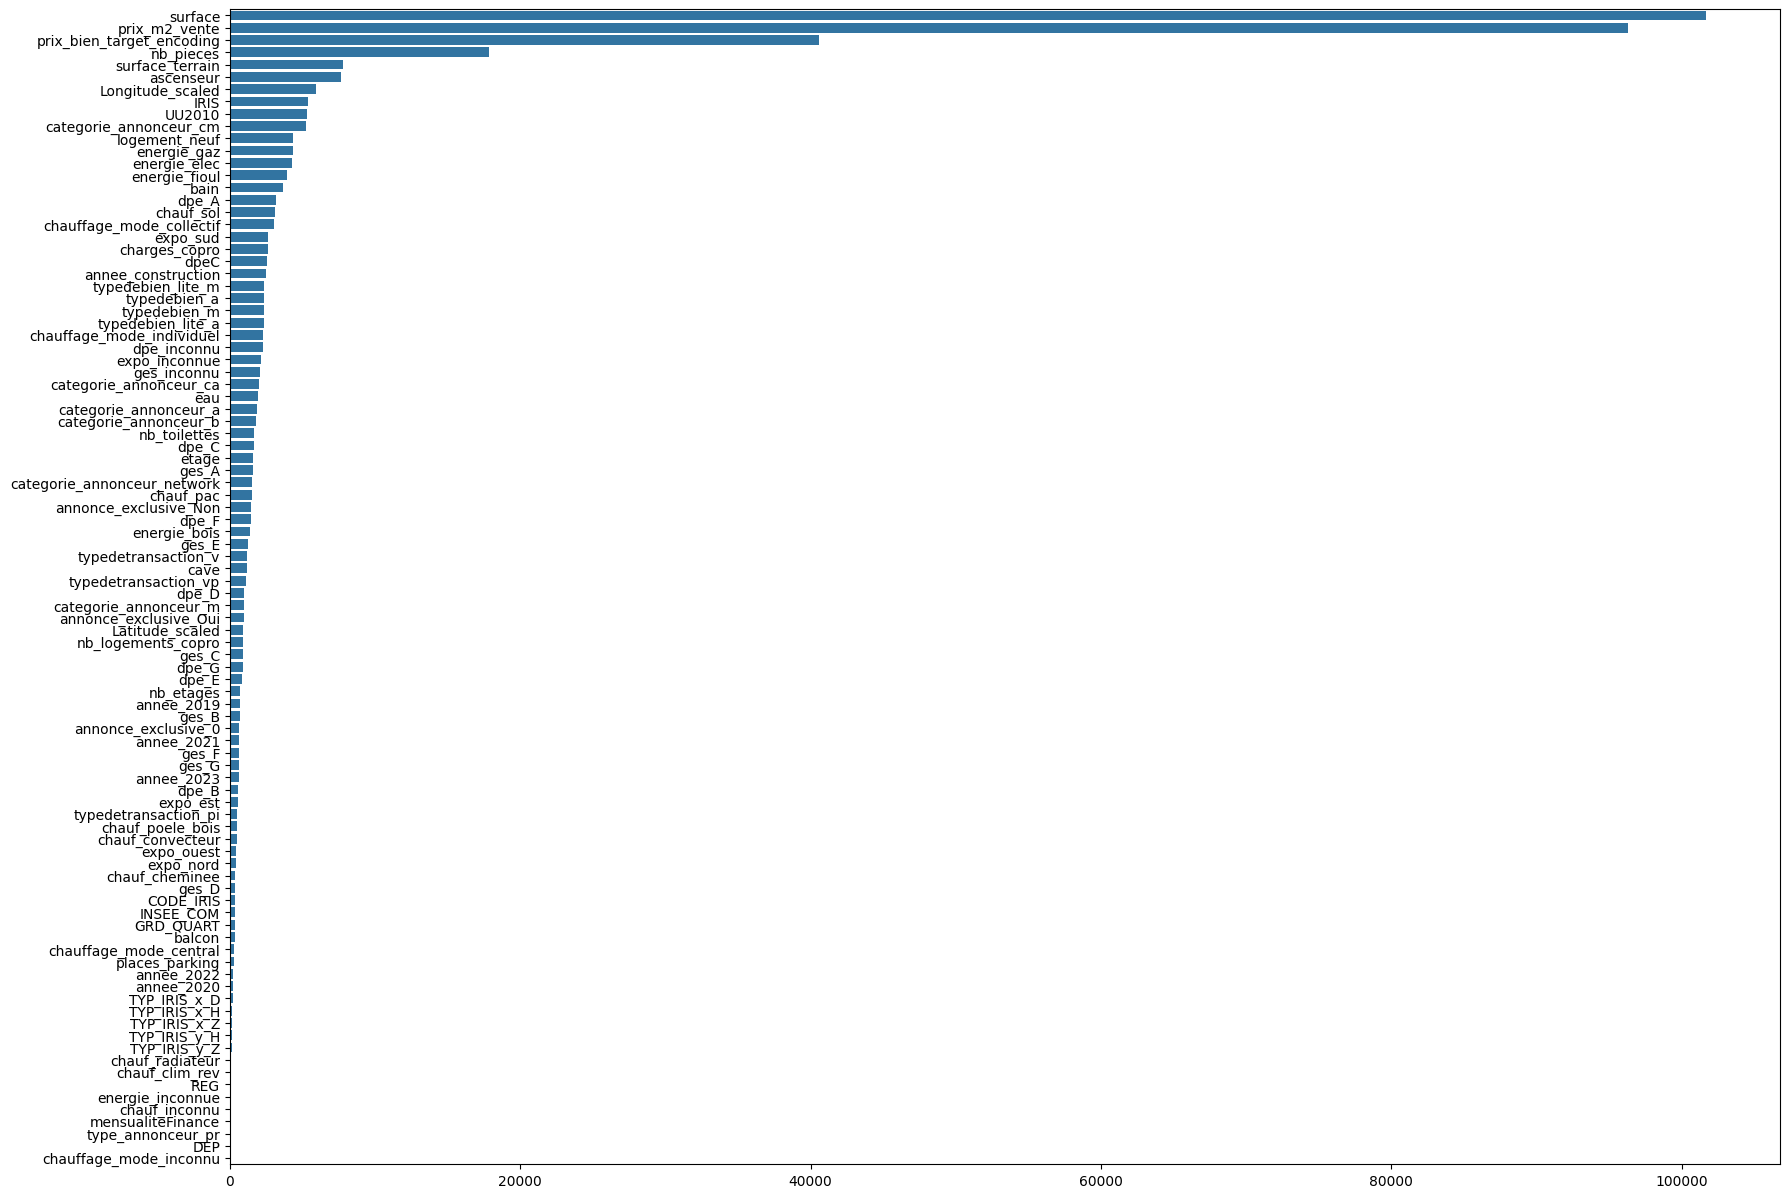

In [27]:
fig, ax = plt.subplots(figsize = (20,15))
sns.barplot(x=columns_coef_trie.values(), y=columns_coef_trie.keys())

LinearRegression en ne gardant que les 10 plus gros coefficient

In [28]:
lr = LinearRegression()
lr.fit(X_train[df_resultats.Feature[:10].values.tolist()], y_train)

# Prédictions
y_pred = lr.predict(X_test[df_resultats.Feature[:10].values.tolist()])

# Scores
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")


MAE  : 32778.69
RMSE : 52717.45
R2   : 0.8903


SequentialFeatureSelector (backward)

Features retenues : Index(['surface', 'surface_terrain', 'nb_pieces', 'eau', 'bain',
       'annee_construction', 'ascenseur', 'charges_copro', 'logement_neuf',
       'IRIS', 'UU2010', 'prix_m2_vente', 'Longitude_scaled',
       'prix_bien_target_encoding', 'chauf_sol', 'dpe_inconnu',
       'typedetransaction_vp', 'annonce_exclusive_Non',
       'categorie_annonceur_cm', 'typedebien_lite_a'],
      dtype='object')
MAE  : 31821.49
RMSE : 51137.84
R2   : 0.8968


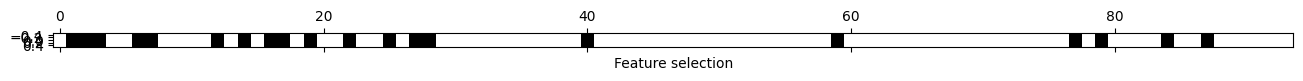

In [29]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold

# Modèle
lr = LinearRegression()

# Backward Selection (recul)
sfs = SequentialFeatureSelector(
    lr,
    n_features_to_select=20,   # à ajuster
    direction="backward",
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring="neg_mean_squared_error"
)

sfs.fit(X_train, y_train.values.ravel())

# Colonnes retenues
mask = sfs.get_support()
selected_features = X_train.columns[mask]

plt.matshow(mask.reshape(1,-1), cmap = 'gray_r')
plt.xlabel('Feature selection');

print("Features retenues :", selected_features)

# Modèle final sur features retenues
lr.fit(X_train[selected_features], y_train)
y_pred = lr.predict(X_test[selected_features])

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")


SelectKBest

Features retenues : Index(['etage', 'surface', 'surface_terrain', 'nb_pieces', 'nb_etages',
       'places_parking', 'nb_toilettes', 'ascenseur', 'nb_logements_copro',
       'prix_m2_vente', 'prix_bien_target_encoding',
       'chauffage_mode_collectif', 'typedebien_a', 'typedebien_m',
       'typedebien_lite_a', 'typedebien_lite_m', 'TYP_IRIS_x_H',
       'TYP_IRIS_x_Z', 'TYP_IRIS_y_H', 'TYP_IRIS_y_Z'],
      dtype='object')
MAE  : 32591.53
RMSE : 52401.15
R2   : 0.8916


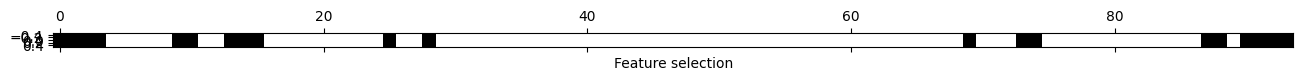

In [30]:
from sklearn.feature_selection import SelectKBest, f_regression

# Choix de K
k = 20

# SelectKBest
selector = SelectKBest(score_func=f_regression, k=k)
selector.fit(X_train, y_train.values.ravel())

# Colonnes retenues
mask = selector.get_support()
kbest_features = X_train.columns[mask]

plt.matshow(mask.reshape(1,-1), cmap = 'gray_r')
plt.xlabel('Feature selection');

print("Features retenues :", kbest_features)

# Modèle final
lr = LinearRegression()
lr.fit(X_train[kbest_features], y_train)

y_pred = lr.predict(X_test[kbest_features])

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")


L'écart de perf entre le modèle prenant l'ensemble des Features et les modèles prenant les 20 features portant le plus d'information est très très faible.

# 15) Modélisation

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Modèle
lr = LinearRegression()
lr.fit(X_train, y_train)

# Prédictions
y_pred = lr.predict(X_test)

# Scores
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")


MAE  : 31428.47
RMSE : 50699.14
R2   : 0.8985
